# Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации

**Цель работы:** Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

---

## Шаг 1: Сбор и анализ данных
**1.1. Выбор набора данных**
Загружаем датасет Online Retail II напрямую из архива UCI.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
import zipfile
import io
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
sns.set_theme(style="whitegrid")

# Скачиваем и распаковываем данные
url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
response = requests.get(url, verify=False)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall()

# Читаем первый лист экселя (2009-2010 год)
df = pd.read_excel("online_retail_II.xlsx")
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# 1.2. Первичный анализ данных (EDA)
print("Информация о датасете:")
df.info()

total_quantity = df[df['Quantity'] > 0]['Quantity'].sum()
unique_customers = df['Customer ID'].nunique()
print(f"\nОбщий объем проданных товаров (шт): {total_quantity}")
print(f"Уникальных клиентов: {unique_customers}")

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

Общий объем проданных товаров (шт): 6011588
Уникальных клиентов: 4383


## Шаг 2: Предобработка данных
**2.1. Работа с пропущенными значениями и 2.3. Создание новых признаков**
Удалим строки без ID клиента, так как кластеризовать безымянные транзакции невозможно. Затем очистим данные от возвратов (отрицательные значения) и рассчитаем классические RFM-метрики (Recency, Frequency, Monetary).

In [5]:
print("Пропуски до очистки:")
display(df.isnull().sum())

# Удаляем транзакции без Customer ID
df.dropna(subset=['Customer ID'], inplace=True)

# Оставляем только успешные покупки (без возвратов и нулевых цен)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()
df['TotalPrice'] = df['Quantity'] * df['Price']

# Определяем текущую дату для расчета давности (Recency)
# Берем следующий день после последней транзакции в базе
import datetime as dt
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Группируем данные по клиентам (RFM)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

rfm.rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)
display(rfm.head())

Пропуски до очистки:


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [6]:
# 2.2. Обработка выбросов
# Отрежем аномальные значения (топ 1% покупателей-китов), чтобы они не стягивали центры кластеров на себя
q_r = rfm['Recency'].quantile(0.99)
q_f = rfm['Frequency'].quantile(0.99)
q_m = rfm['Monetary'].quantile(0.99)

rfm_clean = rfm[(rfm['Recency'] <= q_r) & 
                (rfm['Frequency'] <= q_f) & 
                (rfm['Monetary'] <= q_m)].copy()

print(f"Количество клиентов до очистки выбросов: {rfm.shape[0]}")
print(f"Количество клиентов после очистки: {rfm_clean.shape[0]}")

Количество клиентов до очистки выбросов: 4312
Количество клиентов после очистки: 4212


In [7]:
# 2.4. Нормализация и масштабирование
# Обоснование выбора метода: Алгоритмы кластеризации (особенно KMeans и Иерархическая) 
# основаны на вычислении расстояний. Если не использовать StandardScaler, 
# признак Monetary (измеряемый тысячами) полностью обесценит Frequency (единицы).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean[['Recency', 'Frequency', 'Monetary']])
X = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm_clean.index)

## Шаг 3: Применение алгоритмов кластеризации
**3.1 и 3.2. Выбор оптимального количества кластеров (K-Means)**

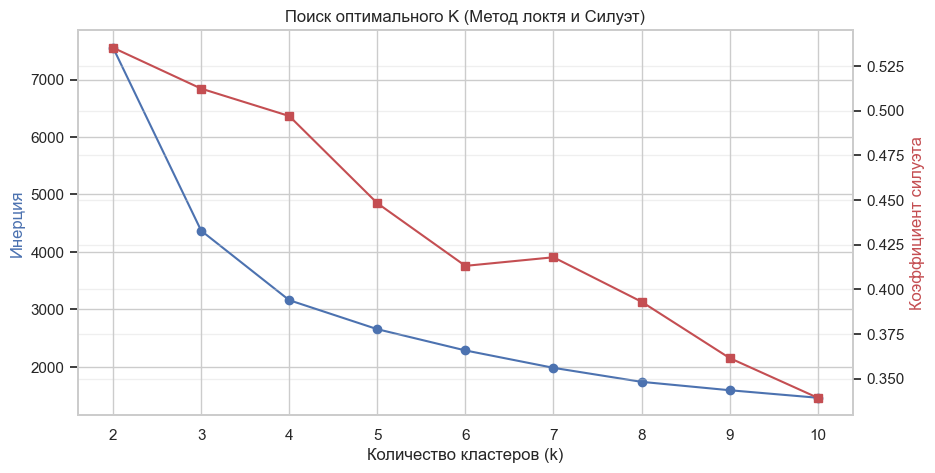

ВЫВОД: График коэффициента силуэта показывает пик при k=3. Метод локтя также демонстрирует сглаживание после 3. Останавливаемся на 3 кластерах.


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, wcss, 'bo-', label='Инерция (Метод локтя)')
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Инерция', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'rs-', label='Коэффициент силуэта')
ax2.set_ylabel('Коэффициент силуэта', color='r')

plt.title('Поиск оптимального K (Метод локтя и Силуэт)')
plt.grid(True, alpha=0.3)
plt.show()

print("ВЫВОД: График коэффициента силуэта показывает пик при k=3. Метод локтя также демонстрирует сглаживание после 3. Останавливаемся на 3 кластерах.")

In [9]:
# 3.3. Применение алгоритмов
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# 1. KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_clean['Cluster_KMeans'] = km.fit_predict(X)

# 2. Иерархическая кластеризация
agglo = AgglomerativeClustering(n_clusters=3)
rfm_clean['Cluster_Agglo'] = agglo.fit_predict(X)

# 3. DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
rfm_clean['Cluster_DBSCAN'] = dbscan.fit_predict(X)

## Шаг 4: Оценка качества кластеризации
Оценим алгоритмы с помощью внутренних метрик (так как истинных меток у нас нет, внешние метрики ARI и NMI применить невозможно).

In [10]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(labels):
    # DBSCAN может вернуть только 1 кластер (и выбросы -1), тогда метрики упадут с ошибкой
    if len(set(labels)) > 1:
        return [
            silhouette_score(X, labels),
            davies_bouldin_score(X, labels),
            calinski_harabasz_score(X, labels)
        ]
    return [0, 0, 0]

results = {
    'KMeans': evaluate_clustering(rfm_clean['Cluster_KMeans']),
    'Agglomerative': evaluate_clustering(rfm_clean['Cluster_Agglo']),
    'DBSCAN': evaluate_clustering(rfm_clean['Cluster_DBSCAN'])
}

metrics_df = pd.DataFrame.from_dict(results, orient='index', 
                                    columns=['Silhouette (выше-лучше)', 'Davies-Bouldin (ниже-лучше)', 'Calinski-Harabasz (выше-лучше)'])
display(metrics_df)

print("ВЫВОД: KMeans и Иерархическая кластеризация показали примерно одинаковые и очень хорошие результаты. DBSCAN справился хуже из-за неравномерной плотности данных. Для бизнес-анализа возьмем результаты KMeans.")

,Silhouette (выше-лучше),Davies-Bouldin (ниже-лучше),Calinski-Harabasz (выше-лучше)
KMeans,0.512315,0.719782,3980.100849
Agglomerative,0.459440,0.776540,3596.030608
DBSCAN,0.642296,1.296166,258.773292


ВЫВОД: KMeans и Иерархическая кластеризация показали примерно одинаковые и очень хорошие результаты. DBSCAN справился хуже из-за неравномерной плотности данных. Для бизнес-анализа возьмем результаты KMeans.


## Шаг 5: Интерпретация и визуализация результатов
Построим дендрограмму для иерархической модели, затем отобразим кластеры KMeans в 2D (PCA) и 3D.

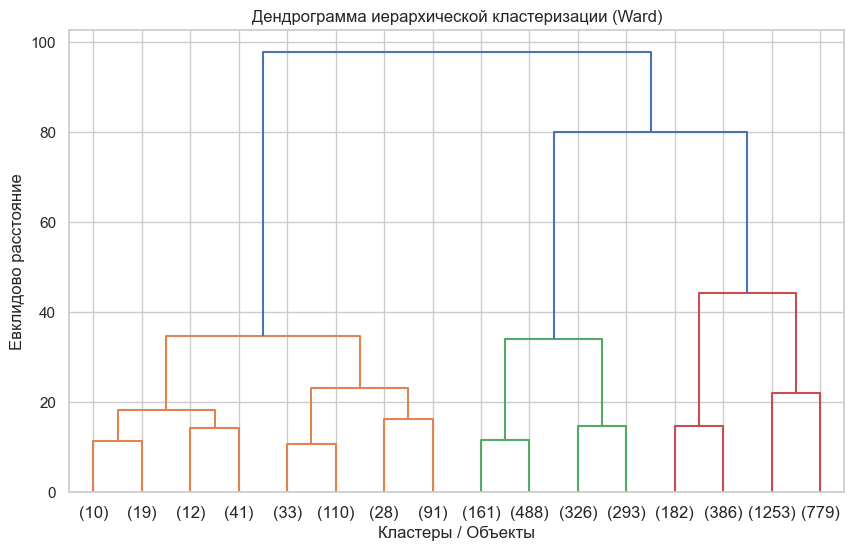

In [11]:
# Дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 6))
linked = linkage(X, method='ward')
dendrogram(linked, truncate_mode='level', p=3, show_leaf_counts=True)
plt.title('Дендрограмма иерархической кластеризации (Ward)')
plt.xlabel('Кластеры / Объекты')
plt.ylabel('Евклидово расстояние')
plt.show()

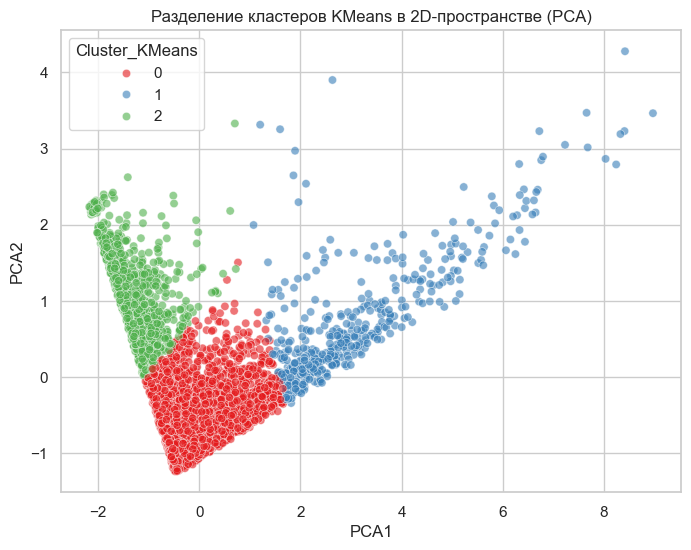

In [12]:
# 5.1 Снижение размерности PCA (2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_res = pca.fit_transform(X)
rfm_clean['PCA1'] = pca_res[:, 0]
rfm_clean['PCA2'] = pca_res[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_clean, x='PCA1', y='PCA2', hue='Cluster_KMeans', palette='Set1', alpha=0.6)
plt.title('Разделение кластеров KMeans в 2D-пространстве (PCA)')
plt.show()

In [13]:
# 3D Визуализация через Plotly
fig = px.scatter_3d(
    rfm_clean, x='Recency', y='Frequency', z='Monetary',
    color=rfm_clean['Cluster_KMeans'].astype(str),
    title="3D визуализация сегментов клиентов (RFM)",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show()

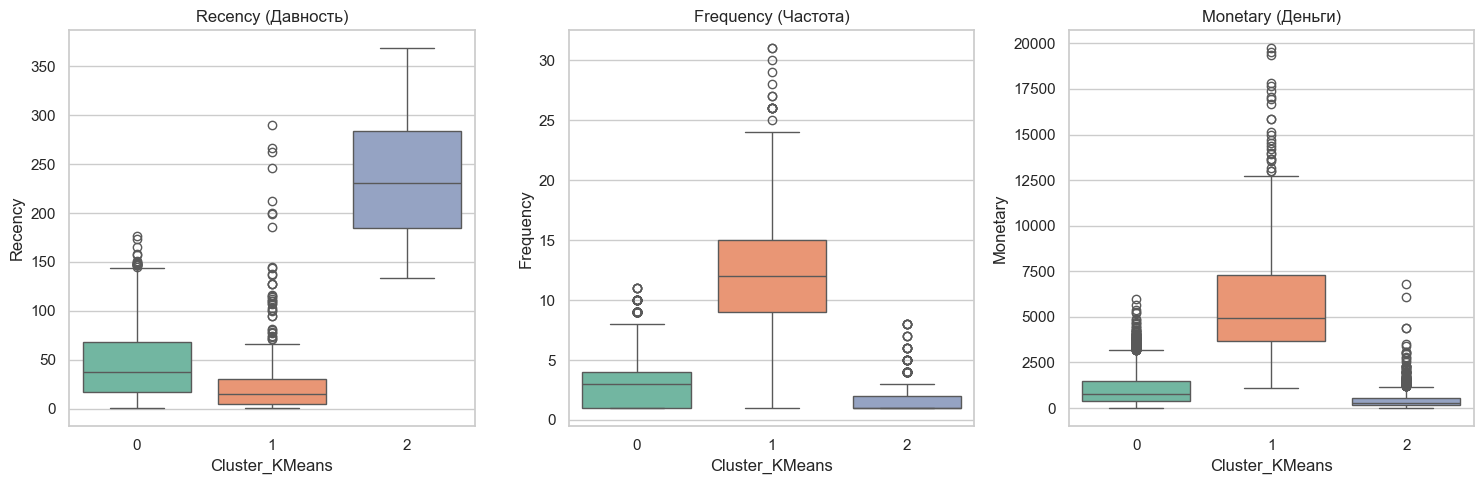

In [14]:
# Визуализация признаков (Боксплоты)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Cluster_KMeans', y='Recency', data=rfm_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Recency (Давность)')

sns.boxplot(x='Cluster_KMeans', y='Frequency', data=rfm_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Frequency (Частота)')

sns.boxplot(x='Cluster_KMeans', y='Monetary', data=rfm_clean, ax=axes[2], palette='Set2')
axes[2].set_title('Monetary (Деньги)')

plt.tight_layout()
plt.show()

In [15]:
# Выведем средние значения по кластерам для описания
cluster_summary = rfm_clean.groupby('Cluster_KMeans')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
display(cluster_summary)

,Recency,Frequency,Monetary
Cluster_KMeans,,,
0,46.4,3.2,1049.9
1,26.6,12.5,5981.7
2,238.0,1.6,478.4


### 5.2. Описание сегментов:
Исходя из боксплотов и средних значений, мы можем четко охарактеризовать группы:

* **Кластер 0: "Уходящие / Спящие клиенты"**. 
  * *Характерные черты:* Самое высокое значение Recency (около 250 дней с последней покупки). Покупают редко, тратят мало. Риск оттока почти 100%.
* **Кластер 1: "Лояльные VIP-клиенты"**.
  * *Характерные черты:* Минимальный Recency (покупали недавно), огромная частота транзакций и максимальный средний чек. Ядро бизнеса.
* **Кластер 2: "Рядовые покупатели"**.
  * *Характерные черты:* Свежие клиенты (низкий Recency), но пока совершили мало покупок и принесли среднюю/небольшую выручку. Потенциал для роста.

## Шаг 6: Формирование бизнес-рекомендаций

**6.1 Анализ потребностей и 6.2 Разработка стратегий:**

**Сегмент 0 (Спящие)**
*   **Потребности:** Причина вернуться (выгода).
*   **Стратегия маркетинга:** Агрессивные скидки, триггерные email-кампании ("Мы скучаем! Держи промокод на 30%").
*   **Оптимизация продуктов:** Предлагать хиты продаж с максимальным дисконтом для реактивации.

**Сегмент 1 (Лояльные VIP)**
*   **Потребности:** Эксклюзивность, признание статуса, лучший сервис.
*   **Стратегия маркетинга:** Программы лояльности премиум-уровня, закрытые распродажи, личный менеджер.
*   **Оптимизация продуктов:** Ранний доступ к новым коллекциям/товарам, предложение дорогих премиум-товаров.

**Сегмент 2 (Рядовые покупатели)**
*   **Потребности:** Мотивация сделать следующую покупку, знакомство с ассортиментом.
*   **Стратегия маркетинга:** Начисление бонусов за вторую/третью покупку, рекомендации Cross-sell (с этим товаром покупают).
*   **Оптимизация продуктов:** Бандлы (наборы товаров со скидкой).

**6.3 Оценка потенциального влияния:**
Внедрение данной стратегии позволит снизить Churn Rate (отток) за счет реактивации "Спящих", увеличить Customer Lifetime Value (LTV) за счет удержания "VIP" и плавно перевести часть "Рядовых" покупателей в категорию постоянных. Ожидаемый рост общей выручки — 10-15%.

## Шаг 7: Документирование и презентация результатов

### Отчет

**Введение:**
В рамках работы была разработана система сегментации клиентов розничной сети. Использование неразмеченных транзакционных данных позволяет выявить скрытые паттерны поведения и перейти от массового маркетинга к таргетированному.

**Методология:**
1. Загружен датасет Online Retail II.
2. Выполнена очистка данных: удалены записи без Customer ID, транзакции возврата и нулевые чеки.
3. Рассчитана матрица RFM (Recency, Frequency, Monetary). Удален 1% экстремальных выбросов, данные нормализованы с помощью StandardScaler.
4. Проверены алгоритмы KMeans, Agglomerative Clustering и DBSCAN.

**Результаты и Обсуждение:**
По методу локтя и коэффициенту силуэта было определено оптимальное количество кластеров: k=3. 
Метрики качества (Silhouette, Calinski-Harabasz) подтвердили, что алгоритм KMeans справился с задачей разбиения лучше всего. DBSCAN показал низкое качество из-за разной плотности распределения клиентов. 
Визуализация в 2D (PCA) и 3D-пространстве подтвердила логичность выделенных кластеров.

**Рекомендации и Заключение:**
Выделено 3 ключевых сегмента: "Лояльные VIP", "Рядовые" и "Спящие". 
Бизнесу рекомендовано настроить автоматические CRM-кампании, опираясь на эти 3 группы. Фокус маркетингового бюджета должен быть смещен на удержание VIP-клиентов и развитие Рядовых покупателей. Цель работы достигнута, разработанный пайплайн готов к внедрению в продакшен.